In [1]:
from sbi_particle_physics.managers.backup import Backup
from sbi_particle_physics.config import DATA_DIR, ACCEPTANCE_COEFFS_PATH, C9, DEFAULT_STRIDE, DEFAULT_PRE_N, DEFAULT_PRERUNS, REAL_DATA
from sbi_particle_physics.objects.model import Model
from sbi_particle_physics.managers.imperfections_diagnostics import ImperfectionsDiagnostics
from sbi_particle_physics.managers.model_diagnostics import ModelDiagnostics
from sbi_particle_physics.managers.real_data import RealData
import torch

In [2]:
device = "cpu" # this small test works on cpu
n_points = 100
model = Model(device, n_points=n_points)

model.set_prior_basic([3], [5])
model.set_simulator(stride=DEFAULT_STRIDE, pre_N=DEFAULT_PRE_N, preruns=DEFAULT_PRERUNS, use_imperfections=True, acceptance_coeffs_path=ACCEPTANCE_COEFFS_PATH)
model.set_normalizer(model.to_tensor([0,0,0,0,0]), model.to_tensor([1,1,1,1,1]))

In [3]:
# q2_range_limits = (4.0, 6.0)
q2_range_limits = (1, 8)

In [ ]:
#data = model.simulate_data_with_parameters(model.to_tensor([[C9]]), n_points=n_points).squeeze(0)
#raw_data = model.normalizer.denormalize_data(data)

In [ ]:
#ImperfectionsDiagnostics.angular_distributions(data=raw_data, q2_bin=q2_range_limits, bins=25)

In [ ]:
#ImperfectionsDiagnostics.q2_distribution(data=raw_data, bins=25)

In [ ]:
n_points2 = 10000 # to compensate acceptance that will remove some points
datasets = ImperfectionsDiagnostics.get_datasets(model, n_points2)

In [ ]:
ImperfectionsDiagnostics.angular_distributions_compare(datasets, q2_bin=q2_range_limits, bins=25)

In [ ]:
ImperfectionsDiagnostics.angular_distributions_compare(datasets, q2_bin=q2_range_limits, bins=25, density=True)

In [ ]:
ImperfectionsDiagnostics.q2_distribution_compare(datasets, bins=40, range_=q2_range_limits)

In [ ]:
ImperfectionsDiagnostics.q2_distribution_compare(datasets, bins=40, range_=q2_range_limits, density=True)

In [ ]:
data_sim, parameters_sim = model.simulate_raw_data(n_samples=100, n_points=n_points)
data_obs, parameter_obs = model.simulate_raw_data(n_samples=1, n_points=n_points)
data_obs = data_obs.squeeze(0)
parameters_sim = parameters_sim.squeeze(0)

In [ ]:
ImperfectionsDiagnostics.chi2_test(x_sim=data_sim, x_obs=data_obs, bins=20, ranges=[q2_range_limits,(-1, 1),(-1, 1),(-torch.pi, torch.pi)])

In [ ]:
ImperfectionsDiagnostics.mmd_test(x_sim=data_sim, x_obs=data_obs)

In [ ]:
ModelDiagnostics.misspecification_test(data_sim, x_o=data_obs)

In [ ]:
ModelDiagnostics.misspecification_test_mmd(data_sim, x_o=data_obs)
# only needs to be between 0.2->0.8 (model is wrong if <0.05)

In [ ]:
# same tests but now with real observed data
real_raw_data = RealData.load_n_points(REAL_DATA, n_points=n_points, device=device)

In [ ]:
ImperfectionsDiagnostics.chi2_test(x_sim=data_sim, x_obs=real_raw_data, bins=20, ranges=[q2_range_limits,(-1, 1),(-1, 1),(-torch.pi, torch.pi)])

In [ ]:
ImperfectionsDiagnostics.mmd_test(x_sim=data_sim, x_obs=real_raw_data)

In [ ]:
ModelDiagnostics.misspecification_test(data_sim, x_o=real_raw_data)

In [ ]:
ModelDiagnostics.misspecification_test_mmd(data_sim, x_o=real_raw_data)
# only needs to be between 0.2->0.8 (model is wrong if <0.05)

In [4]:
x_obs = RealData.load_n_points(REAL_DATA, n_points=10000, device=device)
x_sim_norm = model.simulate_data_with_parameters(model.to_tensor([[C9]]), n_points=10000).squeeze(0)
x_sim = model.normalizer.denormalize_data(x_sim_norm)

Loading LHCb data (partial):   0%|          | 0/40 [00:00<?, ?it/s]

Simulating samples:   0%|          | 0/1 [00:00<?, ?it/s]

/home/hep/nrc25/miniconda3/envs/mlhep/lib/python3.12/site-packages/eos/signal_pdf.py:71: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  log_proposal = pypmc.density.gauss.LocalGauss(sigma)


Pre-runs:   0%|          | 0/10 [00:00<?, ?it/s]

Main run:   0%|          | 0/100 [00:00<?, ?it/s]

Pre-runs:   0%|          | 0/10 [00:00<?, ?it/s]

Main run:   0%|          | 0/100 [00:00<?, ?it/s]

Pre-runs:   0%|          | 0/10 [00:00<?, ?it/s]

Main run:   0%|          | 0/100 [00:00<?, ?it/s]

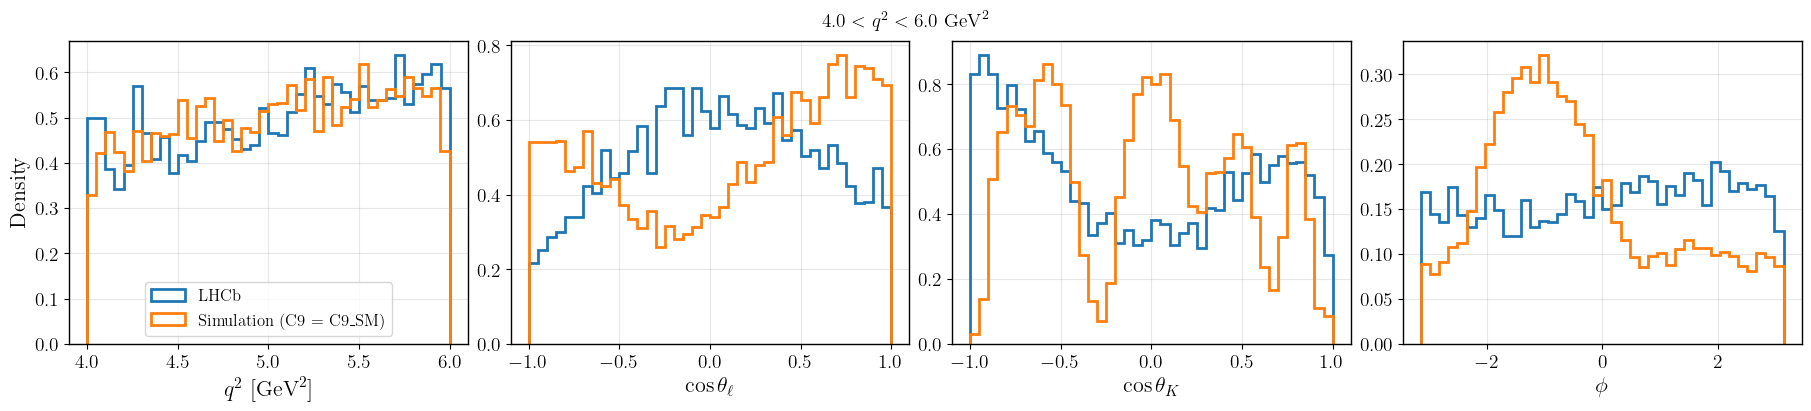

In [5]:
ImperfectionsDiagnostics.compare_real_vs_simulated(x_real=x_obs, x_sim=x_sim, q2_bin=(4.0, 6.0), bins=40, labels=("LHCb", "Simulation (C9 = C9_SM)"))